<a href="https://colab.research.google.com/github/nasarjokar121-boop/safwan/blob/master/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [80]:
def load_data(file_path):
    try:
        df = pd.read_csv("/content/d.csv")
        print("File loaded successfully")
        return df
    except FileNotFoundError:
        print("File not found")
    except Exception as e:
        print("Error:", e)

In [81]:
def explore_data(df):
    print("Shape:", df.shape)
    print("\nColumns:\n", df.columns)
    print("\nInfo:\n")
    print(df.info())
    print("\nDescribe:\n", df.describe())

explore_data(df)

Shape: (891, 14)

Columns:
 Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'FamilySize', 'AgeGroup',
       'Title'],
      dtype='object')

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    object  
 4   Sex          891 non-null    object  
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    object  
 11  FamilySize   891 non-null    int64   
 12  AgeGroup     891 non-null    category
 13  Title        891 non-nu

In [82]:
def handle_missing(df):
    print("\nMissing values:\n", df.isnull().sum())
    df["Age"].fillna(df["Age"].median(), inplace=True)
    df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)
    df.drop("Cabin", axis=1, inplace=True, errors='ignore')
    return df
handle_missing(df)


Missing values:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
FamilySize     0
AgeGroup       0
Title          0
dtype: int64


/tmp/ipython-input-298/2029840765.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipython-input-298/2029840765.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,AgeGroup,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,Young,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,Adult,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,Young,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,Young,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,Young,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,1,Young,Rev
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,1,Young,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,4,Young,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,1,Young,Mr


In [83]:
def filter_data(df):
    result = df[
        (df["Sex"] == "female") &
        (df["Age"] > 30) &
        (df["Pclass"] == 1)
    ]
    print("\nFiltered:\n", result.head())
filter_data(df)



Filtered:
     PassengerId  Survived  Pclass  \
1             2         1       1   
3             4         1       1   
11           12         1       1   
52           53         1       1   
61           62         1       1   

                                                 Name     Sex   Age  SibSp  \
1   Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
3        Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
11                           Bonnell, Miss. Elizabeth  female  58.0      0   
52           Harper, Mrs. Henry Sleeper (Myna Haxtun)  female  49.0      1   
61                                Icard, Miss. Amelie  female  38.0      0   

    Parch    Ticket     Fare Embarked  FamilySize AgeGroup Title  
1       0  PC 17599  71.2833        C           2    Adult   Mrs  
3       0    113803  53.1000        S           2    Young   Mrs  
11      0    113783  26.5500        S           1    Adult  Miss  
52      0  PC 17572  76.7292

In [70]:
def grouping(df):
    print("\nSurvival by gender:")
    print(df.groupby("Sex")["Survived"].mean())
    print("\nAverage fare by class:")
    print(df.groupby("Pclass")["Fare"].mean())
grouping(df)


Survival by gender:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Average fare by class:
Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64


In [84]:
def create_features(df):
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["AgeGroup"] = pd.cut(
        df["Age"],
        bins=[0, 12, 18, 35, 60, 100],
        labels=["Child", "Teen", "Young", "Adult", "Senior"]
    )
    df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)
    return df
create_features(df)

<>:8: SyntaxWarning: invalid escape sequence '\.'
<>:8: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipython-input-298/2957445085.py:8: SyntaxWarning: invalid escape sequence '\.'
  df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,AgeGroup,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,Young,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,Adult,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,Young,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,Young,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,Young,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,1,Young,Rev
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,1,Young,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,4,Young,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,1,Young,Mr


In [85]:
def sorting(df):
    print("\nTop fares:")
    print(df.sort_values("Fare", ascending=False).head())
    print("\nYoungest survivors:")
    print(df[df["Survived"] == 1].sort_values("Age").head())
    print("\nOldest survivors:")
    print(df[df["Survived"] == 1].sort_values("Age", ascending=False).head())
sorting(df)



Top fares:
     PassengerId  Survived  Pclass                                Name  \
679          680         1       1  Cardeza, Mr. Thomas Drake Martinez   
258          259         1       1                    Ward, Miss. Anna   
737          738         1       1              Lesurer, Mr. Gustave J   
88            89         1       1          Fortune, Miss. Mabel Helen   
438          439         0       1                   Fortune, Mr. Mark   

        Sex   Age  SibSp  Parch    Ticket      Fare Embarked  FamilySize  \
679    male  36.0      0      1  PC 17755  512.3292        C           2   
258  female  35.0      0      0  PC 17755  512.3292        C           1   
737    male  35.0      0      0  PC 17755  512.3292        C           1   
88   female  23.0      3      2     19950  263.0000        S           6   
438    male  64.0      1      4     19950  263.0000        S           6   

    AgeGroup Title  
679    Adult    Mr  
258    Young  Miss  
737    Young    Mr  
88

In [86]:
def value_counts(df):
    print("\nSurvived count:")
    print(df["Survived"].value_counts())
    print("\nGender %:")
    print(df["Sex"].value_counts(normalize=True) * 100)
value_counts(df)


Survived count:
Survived
0    549
1    342
Name: count, dtype: int64

Gender %:
Sex
male      64.758698
female    35.241302
Name: proportion, dtype: float64


In [73]:
def statistics(df):
    numeric = df.select_dtypes(include=np.number)
    print("\nMean:\n", numeric.mean())
    print("\nMedian:\n", numeric.median())
    print("\nStd:\n", numeric.std())
    print("\nCorrelation:\n", numeric.corr())
statistics(df)


Mean:
 PassengerId    446.000000
Survived         0.383838
Pclass           2.308642
Age             29.361582
SibSp            0.523008
Parch            0.381594
Fare            32.204208
FamilySize       1.904602
dtype: float64

Median:
 PassengerId    446.0000
Survived         0.0000
Pclass           3.0000
Age             28.0000
SibSp            0.0000
Parch            0.0000
Fare            14.4542
FamilySize       1.0000
dtype: float64

Std:
 PassengerId    257.353842
Survived         0.486592
Pclass           0.836071
Age             13.019697
SibSp            1.102743
Parch            0.806057
Fare            49.693429
FamilySize       1.613459
dtype: float64

Correlation:
              PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.034212 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.064910 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.339898  0.083081  0.01844

In [87]:
def export(df):
    df.to_csv("cleaned_titanic.csv", index=False)
    print("Exported")
    return df
export(df)


Exported


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,AgeGroup,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,Young,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,Adult,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,Young,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,Young,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,Young,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,1,Young,Rev
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,1,Young,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,4,Young,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,1,Young,Mr


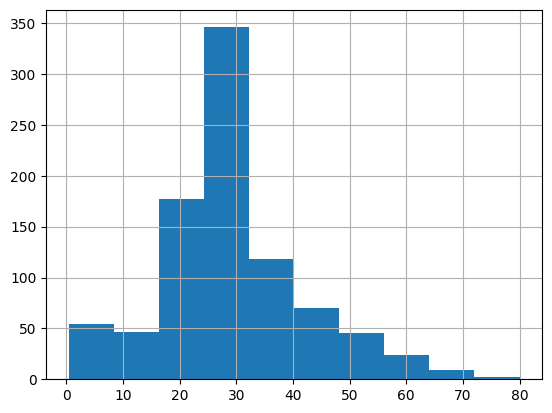

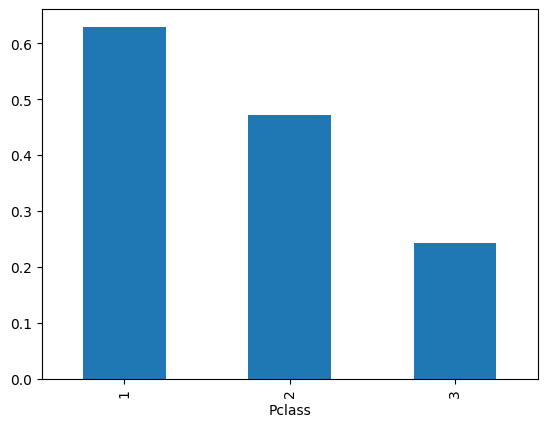

In [88]:
def visualize(df):
    plt.figure()
    df["Age"].hist()
    plt.show()
    plt.figure()
    df.groupby("Pclass")["Survived"].mean().plot(kind="bar")
    plt.show()
visualize(df)



File loaded successfully
Shape: (891, 12)

Columns:
 Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Describe:
        Passen

/tmp/ipython-input-298/2029840765.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipython-input-298/2029840765.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

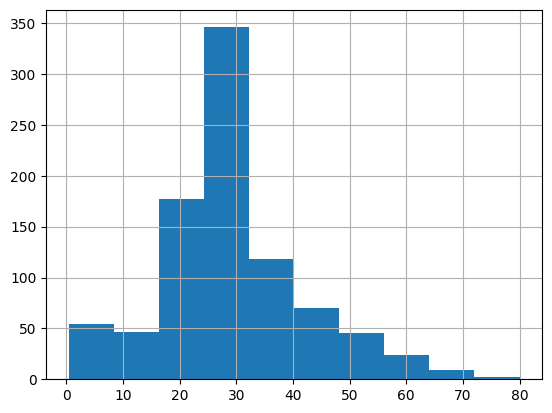

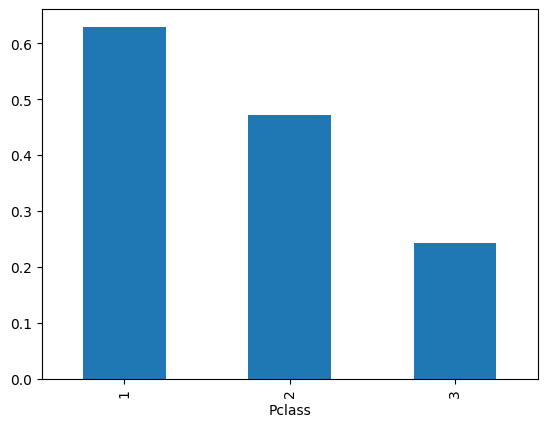

In [89]:
if __name__ == "__main__":
    df = load_data("titanic.csv")
    if df is not None:
        explore_data(df)
        df = handle_missing(df)
        filter_data(df)
        grouping(df)
        df = create_features(df)
        sorting(df)
        value_counts(df)
        statistics(df)
        export(df)
        visualize(df)